
---

# Drone Positioning with PPO + Evolutionary Search

## Overview

We solve the problem of optimally placing $N$ drones on a discrete grid to maximize the probability of communication $P_{\text{comm}}$ for $M$ cellphones. The setup combines two learners:

- **Inner learner (Evolutionary Search, ES):** finds the discrete drone placement $(c_1, \dots, c_N)$ using hyperparameters $(\sigma, z)$.
- **Outer learner (PPO):** learns $(\sigma, z)$ at every reinforcement cycle, adapting the search to the drifting phone distribution.

---

## 1. The Problem

### 1.1 State, action, reward

| Element | Definition |
|---|---|
| **State** $s_t$ | One-hot encoding of drone cells $(c_1,\dots,c_N)$, plus previous $(\sigma_{t-1}, z_{t-1})$, plus bucketed $P_{\text{comm}}$ |
| **Action** $a_t$ | Continuous $(\sigma, z) \in [0,1]^2$ |
| **Reward** $r_t$ | $P_{\text{comm}}$ achieved at the end of cycle $t$, plus a small bonus $\lambda \sigma_t$ |
| **Drone positions** $c_i$ | Discrete — integer grid-cell indices $c_i \in \{0, \dots, K-1\}$ |
| **Transition** | Each cycle: phones drift, RL picks $(\sigma, z)$, ES relocates drones, new $P_{\text{comm}}$ observed |

### 1.2 The physics inside $P_{\text{comm}}$

For each phone, $P_{\text{comm}}$ depends on:

$$
\text{SINR} = \frac{P_{\text{serving}}}{\sum_{\text{interferers}} P_i + N_0}
\quad\Longrightarrow\quad
P_{\text{comm}} = \sigma\!\left(\frac{\text{SINR} - \tau}{T \cdot \text{SINR}}\right)
$$

Improvements come from **frequency reuse**, **power control**, **realistic physical parameters**, and a **softened sigmoid** with temperature $T$.

---

## 2. Why PPO?

### 2.1 The action space is continuous

$(\sigma, z)$ are real-valued. Q-learning requires a discrete action set, which means coarse binning. PPO handles continuous actions natively and smoothly.

### 2.2 PPO in one paragraph

PPO (Proximal Policy Optimization) is an **actor–critic** method that improves the policy with small, trust-region-bounded steps. At each update:

$$
L^{\text{CLIP}}(\theta) = \mathbb{E}\!\left[\min\!\left(r_t(\theta) A_t,\ \operatorname{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\, A_t\right)\right]
$$

where $r_t(\theta) = \pi_\theta(a_t|s_t) / \pi_{\theta_{\text{old}}}(a_t|s_t)$ is the probability ratio and $A_t$ is the advantage. The clip prevents the policy from changing too far in one step, which is what makes PPO stable compared to vanilla policy gradients.

### 2.3 Why not DQN or vanilla PG?

| Method | Why not |
|---|---|
| **DQN** | Requires discretized $(\sigma, z)$ → loses resolution |
| **Vanilla policy gradient** | High variance; unstable |
| **A3C/A2C** | Similar to PPO but less sample-efficient |
| **SAC/TD3** | Off-policy, more complex, unnecessary here since cycles are cheap |

---

## 3. Preventing σ-Collapse

### 3.1 The failure mode

If the RL agent has full control over $\sigma$, it can learn to set $\sigma \to 0$. Why? Because a tiny $\sigma$ means the ES barely moves drones, so $P_{\text{comm}}$ stays stable and **never decreases**. From the RL's perspective, that looks like a safe, high-reward action.

But $\sigma \to 0$ destroys the inner optimizer: the ES no longer explores, and the placement freezes in a local optimum. The overall system has failed even though the RL thinks it succeeded.

### 3.2 Three-layer defense

**Layer 1 — Beta policy (bounded actions, no bias):**

The policy outputs $a \sim \text{Beta}(\alpha, \beta)$ with $\alpha, \beta > 1$. Beta lives natively on $(0,1)$; no `tanh` squashing, no Jacobian correction, no boundary bias. The RL always produces valid actions.

**Layer 2 — Structural floor:**

$$
\sigma = \sigma_{\min} + a \cdot (\sigma_{\max} - \sigma_{\min}), \quad \sigma_{\min} = 0.15
$$

Even if $a = 0$, $\sigma$ cannot go below 0.15. The ES always explores at least 15% of drones per step. **Collapse is mathematically impossible.**

**Layer 3 — Small monotone bonus:**

$$
r_t = P_{\text{comm}} + \lambda \cdot \sigma_t, \quad \lambda = 0.03
$$

The bonus is monotone in $\sigma$, so the RL has a *slight* preference for larger $\sigma$ — enough to nudge it away from the floor, small enough that it won't sacrifice $P_{\text{comm}}$ just to inflate the bonus.

### 3.3 What NOT to do

- ❌ **Clip $\sigma$ inside the policy head.** Gradient is then calculated for a *different* action than the one taken → biased updates.
- ❌ **Set a huge reward bonus for $\sigma$.** RL will maximize $\sigma$ regardless of $P_{\text{comm}}$.
- ❌ **Use ε-greedy with a decaying ε as the only exploration source.** It doesn't solve the underlying incentive problem.

---

## 4. Reward Design — The Hard Part

### 4.1 Why combining RL and GA is tricky

Genetic/evolutionary algorithms **need exploration** to work. RL typically wants to **exploit** the best-known action. When RL controls the GA's exploration rate, these two objectives collide:

| Player | Wants |
|---|---|
| RL | Maximize reward (P_comm) → often prefers safe, low-variance actions |
| GA | Explore enough to escape local optima → needs a large $\sigma$ |

If RL controls $\sigma$, it will naturally drive it toward the safe minimum. This is not a bug — it's exactly what the RL objective asks for. The reward must be designed to align them.

### 4.2 Three reward formulations

**Option A — Raw $P_{\text{comm}}$ (recommended):**

$$
r_t = P_{\text{comm}} + \lambda \sigma_t
$$

- ✔ Directly matches the stated goal.
- ✔ No shaping bias.
- ⚠️ RL is indifferent to $\sigma$ if $P_{\text{comm}}$ is flat — the bonus term prevents floor collapse.

**Option B — Improvement (Δ$P_{\text{comm}}$):**

$$
r_t = P_{\text{comm},t} - P_{\text{comm},t-1}
$$

- ✔ Encourages change; punishes stagnation.
- ❌ Near the optimum, reward → 0 → **no learning signal**. RL oscillates randomly.

**Option C — Horizon-averaged improvement:**

$$
r_t = \overline{P_{\text{comm}}}_{\text{recent}} - \overline{P_{\text{comm}}}_{\text{older}}
$$

- ✔ Credits exploration that pays off across cycles.
- ❌ Complex; the two halves can fight each other in the early phase.

### 4.3 The subtle failure of Δ-rewards

When $P_{\text{comm}}$ is near its ceiling, every action gives Δ ≈ 0, so the reward has **zero gradient**. PPO can't distinguish good $(\sigma, z)$ from bad ones. The policy wanders.

**Fix:** use **raw $P_{\text{comm}}$** (Option A). The reward is always a positive signal, and the small $\sigma$-bonus prevents the RL from being indifferent to exploration.

### 4.4 Checklist for a healthy reward

- ✅ The primary term equals the *actual* objective ($P_{\text{comm}}$).
- ✅ Any auxiliary term is *small* relative to the primary.
- ✅ The reward is *non-zero* everywhere the policy might land.
- ✅ Reward is monotone in the desired direction — no weird cliffs.

---

## 5. What Each Component Contributes

| Component | Role |
|---|---|
| **PPO (Beta)** | Learns $(\sigma, z)$ robustly, adapts to phone drift |
| **Inner ES** | Solves the combinatorial placement problem cheaply |
| **Beta policy** | Bounded, unbiased actions in $(0,1)$ |
| **σ floor** | Structural prevention of exploration collapse |
| **σ bonus** | Minor nudge away from the floor |
| **Frequency reuse** | Removes cross-channel interference (biggest P_comm gain) |
| **Power control** | Reduces interference from peripheral drones |
| **Softened sigmoid** | Gives partial credit at moderate SINR |
| **Domain randomization** | Prevents overfitting to training phone layout |

---

## 6. Quick Reference — Common Pitfalls

| Symptom | Likely cause | Fix |
|---|---|---|
| $\sigma$ hovers at floor | Bonus too small | Increase $\lambda$ to 0.05 |
| $\sigma$ oscillates wildly | Over-training / LR too high | Reduce LR, add early stopping |
| $P_{\text{comm}}$ plateaus below 0.5 | Physics model too harsh | Frequency reuse, realistic params |
| Test much worse than train | Overfitting to training phones | Domain randomization |
| PPO loss spikes | LR too high, batches too small | Reduce LR, increase batch size |
| Policy biased near boundaries | Used `tanh` without Jacobian | Switch to Beta policy |

---

## 7. The Big Picture

```
   ┌──────────────────────────────────────────────────────────────┐
   │                                                              │
   │   PPO agent ──(σ, z)──> Evolutionary Search ──(c₁..c_N)──>   │
   │      ▲                        │                        P_comm │
   │      │                        │                              │
   │      └───────── reward ◄──────┴──────────────────────────────┘
   │                                                              │
   └──────────────────────────────────────────────────────────────┘
```

- **PPO** answers: *how aggressively should I search right now?*
- **ES** answers: *where exactly should the drones go?*
- **Reward** ties them together: *did the placement actually improve?*

The key insight: **the RL controls the search strategy, not the search itself**. This decomposition makes both problems tractable and keeps the RL's action space small (2D), which is what makes PPO a stable, effective choice here.

---

## 8. Suggested Reading Order in the Notebook

1. **Environment** — understand the physics of $P_{\text{comm}}$
2. **Inner ES** — see how $(\sigma, z)$ shape the search
3. **PPO agent** — Beta policy, clipping, critic
4. **Training loop** — reward = $P_{\text{comm}} + 0.03\sigma$
5. **Diagnostics** — SINR histogram, P_comm curve
6. **Testing** — frozen policy on unseen phone layouts
7. **Failure analysis** — try disabling the σ-floor and watch collapse happen

CONFIGURATION
Grid                : 5x5 (25 squares)
State dim           : 212
Bandwidth           : 100.0 MHz
Tx power            : 30.0 dBm
Channels (reuse)    : 3
Power control       : True
Sigmoid temperature : 0.5
Reward              : P_comm + 0.03·σ
σ range             : [0.15, 0.7]

--- DIAGNOSTIC: initial random placement ---
Channels         : 3
Bandwidth        : 100.0 MHz  (33.3 per channel)
Tx power (max)   : 30.0 dBm  (power control: True)
SINR dB   : min=0.0 med=14.3 max=54.2
Fraction with SINR > 0 dB: 1.00
P_comm                   : 0.7303

PHASE 1: TRAINING
[train  10] P_comm=0.7293 σ=0.413 z=0.507 r=+0.7417
[train  20] P_comm=0.7274 σ=0.522 z=0.461 r=+0.7431
[train  30] P_comm=0.7359 σ=0.502 z=0.746 r=+0.7510
[train  40] P_comm=0.7316 σ=0.453 z=0.519 r=+0.7452
[train  50] P_comm=0.7330 σ=0.497 z=0.670 r=+0.7479
[train  60] P_comm=0.7430 σ=0.346 z=0.304 r=+0.7534
[train  70] P_comm=0.7453 σ=0.489 z=0.711 r=+0.7599
[train  80] P_comm=0.7456 σ=0.561 z=0.367 r=+0.7624
[tr

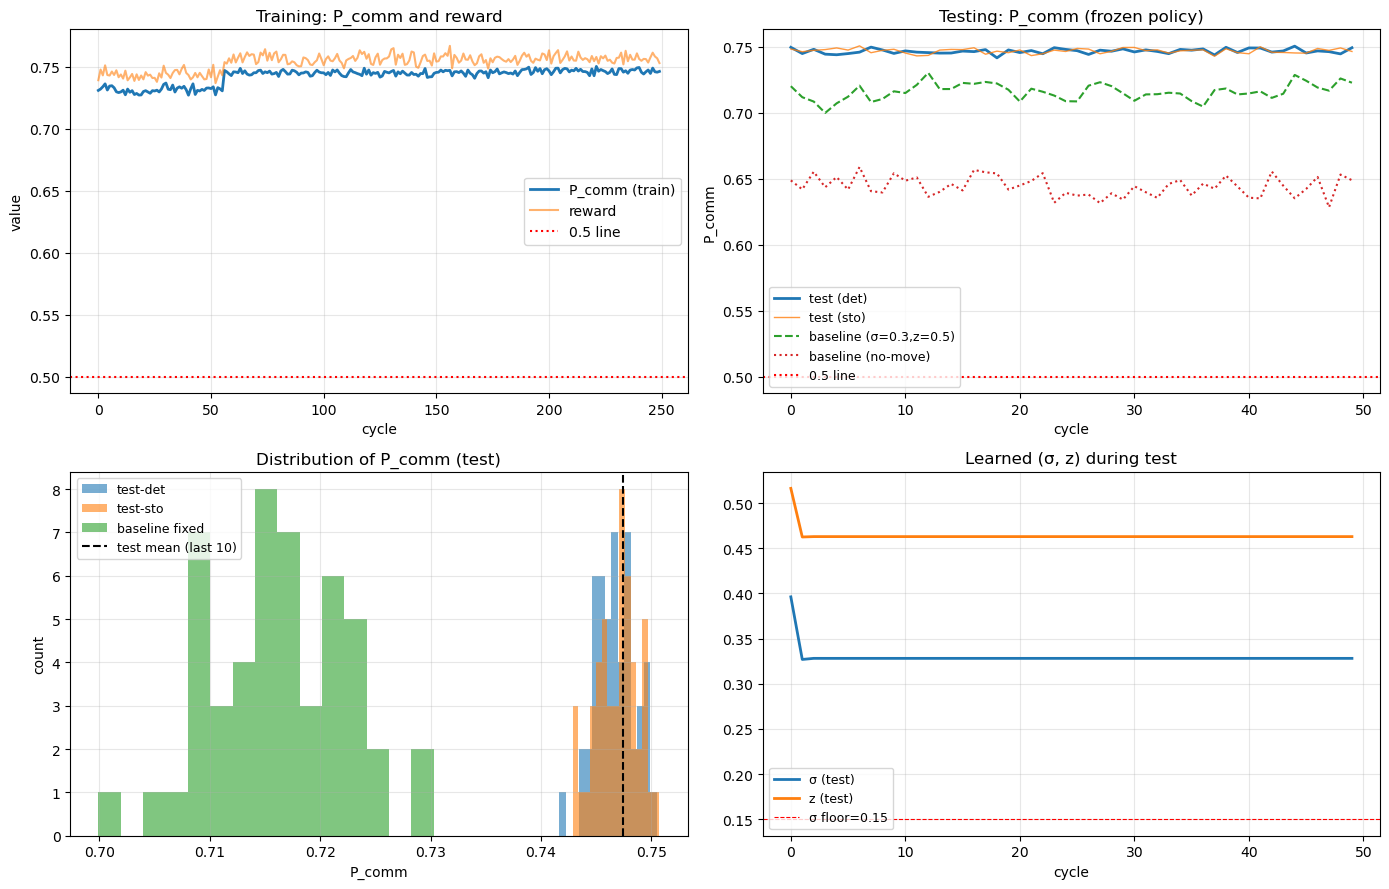

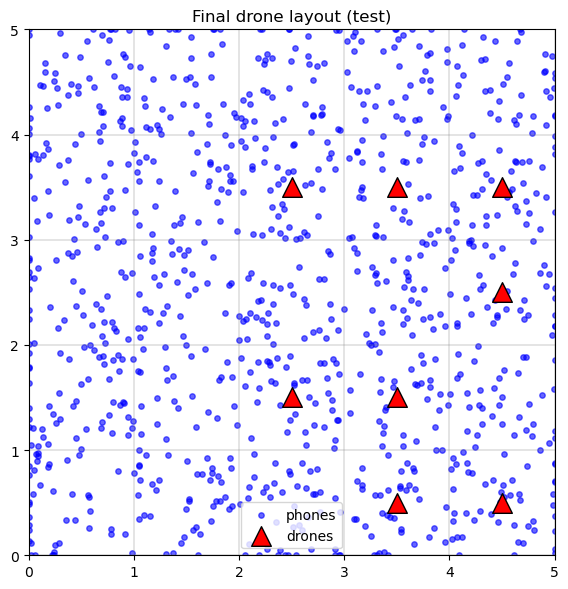

In [1]:
"""
Integrated PPO + ES — DRONE POSITIONING with ALL FIXES
=======================================================
Fixes applied:
  [A1] Frequency reuse across C channels (interference ↓↓)
  [A2] Power control (serving drones use minimal needed power)
  [C]  Softened sigmoid temperature T
  [D]  Realistic physical parameters (100 MHz, 30 dBm, suburban)
  [σ]  Beta policy + structural floor + small bonus (no collapse)
  [R]  Reward = P_comm + λ·σ

Drone positions ci are DISCRETE (integer grid-cell indices).
PPO learns continuous (sigma, z) in [0,1]; ES searches grid placements.
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributions as D
import random
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.special import expit


# ======================================================================
# 1. ENVIRONMENT (with frequency reuse + power control)
# ======================================================================
class DroneNetworkEnv:
    def __init__(self,
                 N_drones=8,
                 L_km2=25.0,
                 r_km=1.0,
                 M_phones=50,
                 # --- FIX D: realistic physical parameters ---
                 bandwidth_MHz=100.0,       # was 20
                 noise_power_dBm=-104.0,    # was -100
                 tx_power_dBm=30.0,         # was 23
                 frequency_GHz=3.5,         # was 2.4
                 path_loss_exp=2.2,         # was 2.5 (suburban)
                 shadowing_std=6.0,         # was 8
                 phone_drift_std=0.2,       # was 0.3
                 # --- FIX A1: frequency reuse ---
                 n_channels=3,
                 # --- FIX C: sigmoid temperature ---
                 sigmoid_T=0.5,
                 # --- FIX A2: power control ---
                 power_control=True,
                 seed=0):
        rng = np.random.default_rng(seed)
        self.rng = rng
        self.N = N_drones
        self.L = L_km2
        self.r = r_km
        self.M = M_phones
        self.B_total = bandwidth_MHz
        self.noise_dBm = noise_power_dBm
        self.tx_dBm = tx_power_dBm
        self.freq = frequency_GHz
        self.alpha = path_loss_exp
        self.shadow = shadowing_std
        self.drift = phone_drift_std
        self.C = n_channels
        self.sigmoid_T = sigmoid_T
        self.power_control = power_control

        self.grid_size = int(round(np.sqrt(self.L) / self.r))
        self.num_squares = self.grid_size ** 2

        self.phone_positions = rng.uniform(
            0, self.grid_size * self.r, (self.M, 2))
        self.drone_grid = rng.choice(self.num_squares, self.N, replace=False)
        self.drone_positions = self._grid_to_pos(self.drone_grid)

    def _grid_to_pos(self, grid_idx):
        pos = np.zeros((len(grid_idx), 2))
        for i, g in enumerate(grid_idx):
            row, col = divmod(int(g), self.grid_size)
            pos[i] = [(col + 0.5) * self.r, (row + 0.5) * self.r]
        return pos

    def drift_phones(self):
        step = self.rng.normal(0, self.drift, (self.M, 2))
        self.phone_positions = np.clip(
            self.phone_positions + step, 0, self.grid_size * self.r)

    def path_loss(self, d_km):
        d_km = np.maximum(d_km, 0.01)
        fspl_1 = 20 * np.log10(self.freq * 1e9) - 147.55
        pl = fspl_1 + 10 * self.alpha * np.log10(d_km)
        return pl + self.rng.normal(0, self.shadow, pl.shape)

    def _effective_tx_power_dBm(self, drone_positions, distances):
        """
        [FIX A2] Power control: each drone reduces tx power based on the
        distance to its closest phone in each channel. Far drones that
        cannot serve a phone well transmit less, reducing interference.
        Returns an (N, M) effective tx power matrix in dBm.
        """
        if not self.power_control:
            return np.full(distances.shape, self.tx_dBm)

        # Minimum distance from each drone to any phone (proxy for "how
        # useful this drone is"). Drones far from all phones → low power.
        min_d = distances.min(axis=1, keepdims=True)     # (N, 1)
        # Coverage radius: cell diagonal
        R = self.r * np.sqrt(2)
        # Scale tx power: full power when min_d < R, drops with distance
        # Floor at 10 dB below max to avoid completely silent drones
        scale_dB = -10.0 * np.clip(
            (min_d - R) / R, 0, 3.0)                     # 0 to -30 dB
        effective = self.tx_dBm + scale_dB
        return np.broadcast_to(effective, distances.shape).copy()

    def p_comm(self, drone_positions):
        """
        Communication probability with:
          [A1] frequency reuse (drones assigned to channel i mod C)
          [A2] power control
          [C]  softened sigmoid
        """
        d = cdist(drone_positions, self.phone_positions)      # (N, M)
        pl = self.path_loss(d)                                 # (N, M)

        # Effective tx power per (drone, phone)
        tx_eff = self._effective_tx_power_dBm(drone_positions, d)
        rx_mW = 10 ** ((tx_eff - pl) / 10)                    # (N, M)

        # --- Frequency reuse: each drone assigned to channel i mod C ---
        channel_of_drone = np.arange(self.N) % self.C
        B_per_channel = self.B_total / self.C
        noise = 10 ** (self.noise_dBm / 10)

        # Each phone is served by exactly one channel (the one with the
        # strongest drone on that channel); interference only from other
        # drones on the SAME channel.
        best_sinr_per_channel = np.zeros((self.C, self.M))
        for c in range(self.C):
            mask = channel_of_drone == c
            if not mask.any():
                best_sinr_per_channel[c] = 0
                continue
            rx_c = rx_mW[mask]                                # (nc, M)
            best_c = rx_c.max(axis=0)
            interf_c = rx_c.sum(axis=0) - best_c
            sinr_c = best_c / (interf_c + noise + 1e-12)
            best_sinr_per_channel[c] = sinr_c

        sinr = best_sinr_per_channel.max(axis=0)              # (M,)

        # Proportional-fair bandwidth within the serving channel
        rates = np.log2(1 + sinr)
        total_rate = rates.sum() + 1e-12
        bw = B_per_channel * rates / total_rate
        # Fair-share per phone across the whole system
        fair_share = self.B_total / self.M
        bw_factor = bw / fair_share

        # --- FIX C: softened sigmoid ---
        thr = 1.0 / bw_factor
        T = self.sigmoid_T
        p = expit((sinr - thr) / (T * sinr + 1e-12))
        return float(np.mean(p))

    def state_vector(self, last_sigma, last_z, last_pcomm):
        onehot = np.zeros(self.N * self.num_squares, dtype=np.float32)
        for i, g in enumerate(self.drone_grid):
            onehot[i * self.num_squares + int(g)] = 1.0
        p_bucket = int(np.clip(last_pcomm, 0, 1) * 9.999)
        p_onehot = np.zeros(10, dtype=np.float32)
        p_onehot[p_bucket] = 1.0
        return np.concatenate(
            [onehot, [last_sigma, last_z], p_onehot]).astype(np.float32)

    @property
    def state_dim(self):
        return self.N * self.num_squares + 2 + 10


# ======================================================================
# 2. INNER OPTIMIZER (ES over discrete grid)
# ======================================================================
class EvolutionarySearch:
    def __init__(self, env, lam=8):
        self.env = env
        self.lam = lam

    def run(self, sigma, z, steps=15):
        N = self.env.N
        num_sq = self.env.num_squares
        parent = self.env.drone_grid.copy()
        parent_fit = self.env.p_comm(self.env._grid_to_pos(parent))
        best, best_fit = parent.copy(), parent_fit

        for _ in range(steps):
            children = []
            for _ in range(self.lam):
                child = parent.copy()
                mask = self.env.rng.random(N) < sigma
                if sigma > 0 and not mask.any():
                    mask[self.env.rng.integers(N)] = True
                for i in np.where(mask)[0]:
                    new_cell = self.env.rng.integers(num_sq)
                    while new_cell == child[i]:
                        new_cell = self.env.rng.integers(num_sq)
                    child[i] = new_cell
                children.append(child)
            fits = np.array([
                self.env.p_comm(self.env._grid_to_pos(c)) for c in children])
            keep = max(1, int(round(z * self.lam)))
            top_idx = np.argsort(fits)[-keep:]
            cand = children[top_idx[0]]
            cand_fit = fits[top_idx[0]]
            if cand_fit > parent_fit:
                parent, parent_fit = cand, cand_fit
            if parent_fit > best_fit:
                best, best_fit = parent.copy(), parent_fit
        return best, best_fit


# ======================================================================
# 3. PPO AGENT (Beta policy, unbiased, bounded)
# ======================================================================
class PPOAgentBeta:
    def __init__(self, state_dim, lr=3e-4, gamma=0.95, lam=0.95,
                 clip=0.2, epochs=10, batch=64):
        self.gamma, self.lam, self.clip = gamma, lam, clip
        self.epochs, self.batch = epochs, batch

        self.alpha_head = nn.Sequential(
            nn.Linear(state_dim, 128), nn.Tanh(),
            nn.Linear(128, 2))
        self.beta_head = nn.Sequential(
            nn.Linear(state_dim, 128), nn.Tanh(),
            nn.Linear(128, 2))
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1))
        self.opt = optim.Adam(
            list(self.alpha_head.parameters())
            + list(self.beta_head.parameters())
            + list(self.critic.parameters()), lr=lr)

    def _dist(self, s):
        # +2 keeps Beta unimodal and low-variance
        alpha = torch.nn.functional.softplus(self.alpha_head(s)) + 2.0
        beta = torch.nn.functional.softplus(self.beta_head(s)) + 2.0
        return D.Beta(alpha, beta)

    def act(self, state_np, deterministic=False):
        with torch.no_grad():
            s = torch.as_tensor(state_np, dtype=torch.float32).unsqueeze(0)
            d = self._dist(s)
            if deterministic:
                a_mode = (d.concentration1 - 1) / (
                    d.concentration1 + d.concentration0 - 2 + 1e-9)
                return a_mode.squeeze(0).numpy(), 0.0
            a = d.sample()
            logp = d.log_prob(a).sum(-1)
        return a.squeeze(0).numpy(), float(logp.item())

    def update(self, traj):
        S = torch.as_tensor(np.stack(traj['s']), dtype=torch.float32)
        A = torch.as_tensor(np.stack(traj['a']), dtype=torch.float32)
        LP = torch.as_tensor(traj['logp'], dtype=torch.float32)
        R = torch.as_tensor(traj['ret'], dtype=torch.float32)
        ADV = (R - R.mean()) / (R.std() + 1e-8)

        for _ in range(self.epochs):
            idx = torch.randperm(len(S))
            for start in range(0, len(S), self.batch):
                j = idx[start:start + self.batch]
                d = self._dist(S[j])
                logp = d.log_prob(A[j].clamp(1e-6, 1 - 1e-6)).sum(-1)
                ratio = torch.exp(logp - LP[j])
                surr1 = ratio * ADV[j]
                surr2 = torch.clamp(ratio, 1 - self.clip, 1 + self.clip) * ADV[j]
                actor_loss = -torch.min(surr1, surr2).mean()
                value = self.critic(S[j]).squeeze(-1)
                critic_loss = ((value - R[j]) ** 2).mean()
                loss = actor_loss + 0.5 * critic_loss
                self.opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    list(self.alpha_head.parameters())
                    + list(self.beta_head.parameters())
                    + list(self.critic.parameters()), 0.5)
                self.opt.step()


# ======================================================================
# 4. MAPS (structural σ-floor)
# ======================================================================
SIGMA_FLOOR, SIGMA_CEILING = 0.15, 0.70
Z_FLOOR, Z_CEILING = 0.10, 0.95

def map_sigma(a0): return SIGMA_FLOOR + a0 * (SIGMA_CEILING - SIGMA_FLOOR)
def map_z(a1):     return Z_FLOOR + a1 * (Z_CEILING - Z_FLOOR)


# ======================================================================
# 5. TRAINING (reward = P_comm + λ·σ)
# ======================================================================
def train(env, agent, es, n_cycles=250, es_steps=15, update_every=10,
          sigma_bonus=0.03, verbose=True):
    traj = {'s': [], 'a': [], 'logp': [], 'r': []}
    last_sigma, last_z = 0.3, 0.5
    last_pcomm = env.p_comm(env.drone_positions)
    p_hist, sigma_hist, z_hist, reward_hist = [], [], [], []

    for t in range(n_cycles):
        s = env.state_vector(last_sigma, last_z, last_pcomm)
        a, logp = agent.act(s)
        sigma = map_sigma(float(a[0]))
        z = map_z(float(a[1]))

        env.drift_phones()
        best_grid, best_fit = es.run(sigma, z, steps=es_steps)
        env.drone_grid = best_grid
        env.drone_positions = env._grid_to_pos(best_grid)

        # --- REWARD = P_comm + small σ bonus ---
        reward = best_fit + sigma_bonus * sigma

        traj['s'].append(s)
        traj['a'].append(a)
        traj['logp'].append(logp)
        traj['r'].append(reward)
        p_hist.append(best_fit)
        sigma_hist.append(sigma)
        z_hist.append(z)
        reward_hist.append(reward)
        last_sigma, last_z, last_pcomm = sigma, z, best_fit

        if (t + 1) % update_every == 0:
            R, G = [], 0.0
            for r in reversed(traj['r']):
                G = r + agent.gamma * G
                R.insert(0, G)
            traj['ret'] = R
            agent.update(traj)
            traj = {'s': [], 'a': [], 'logp': [], 'r': []}
            if verbose:
                print(f"[train {t+1:3d}] P_comm={best_fit:.4f} "
                      f"σ={sigma:.3f} z={z:.3f} r={reward:+.4f}")
        elif verbose and (t + 1) % 10 == 0:
            print(f"[train {t+1:3d}] P_comm={best_fit:.4f} "
                  f"σ={sigma:.3f} z={z:.3f} r={reward:+.4f}")

    return dict(p=p_hist, sigma=sigma_hist, z=z_hist, reward=reward_hist)


# ======================================================================
# 6. TEST / EVALUATION (frozen policy, fresh env)
# ======================================================================
def evaluate(agent, env, es, n_cycles=50, es_steps=15,
             deterministic=True, label="Test", verbose=True):
    env.phone_positions = env.rng.uniform(
        0, env.grid_size * env.r, (env.M, 2))
    env.drone_grid = env.rng.choice(env.num_squares, env.N, replace=False)
    env.drone_positions = env._grid_to_pos(env.drone_grid)

    last_sigma, last_z = 0.3, 0.5
    last_pcomm = env.p_comm(env.drone_positions)
    p_hist, sigma_hist, z_hist = [], [], []

    if verbose:
        print(f"\n--- {label} ({n_cycles} cycles, det={deterministic}) ---")
    for t in range(n_cycles):
        s = env.state_vector(last_sigma, last_z, last_pcomm)
        a, _ = agent.act(s, deterministic=deterministic)
        sigma = map_sigma(float(a[0]))
        z = map_z(float(a[1]))

        env.drift_phones()
        best_grid, best_fit = es.run(sigma, z, steps=es_steps)
        env.drone_grid = best_grid
        env.drone_positions = env._grid_to_pos(best_grid)

        p_hist.append(best_fit)
        sigma_hist.append(sigma)
        z_hist.append(z)
        last_sigma, last_z, last_pcomm = sigma, z, best_fit

        if verbose and (t + 1) % 10 == 0:
            print(f"[{label} {t+1:3d}] P_comm={best_fit:.4f} "
                  f"σ={sigma:.3f} z={z:.3f}")

    return dict(p=p_hist, sigma=sigma_hist, z=z_hist)


# ======================================================================
# 7. BASELINES
# ======================================================================
def baseline_fixed(env, n_cycles=50, es_steps=15, sigma=0.3, z=0.5):
    env.phone_positions = env.rng.uniform(
        0, env.grid_size * env.r, (env.M, 2))
    env.drone_grid = env.rng.choice(env.num_squares, env.N, replace=False)
    env.drone_positions = env._grid_to_pos(env.drone_grid)
    es = EvolutionarySearch(env, lam=8)
    p_hist = []
    for _ in range(n_cycles):
        env.drift_phones()
        best_grid, best_fit = es.run(sigma=sigma, z=z, steps=es_steps)
        env.drone_grid = best_grid
        env.drone_positions = env._grid_to_pos(best_grid)
        p_hist.append(best_fit)
    return p_hist


def baseline_no_move(env, n_cycles=50):
    env.phone_positions = env.rng.uniform(
        0, env.grid_size * env.r, (env.M, 2))
    env.drone_grid = env.rng.choice(env.num_squares, env.N, replace=False)
    env.drone_positions = env._grid_to_pos(env.drone_grid)
    p_hist = []
    for _ in range(n_cycles):
        env.drift_phones()
        p_hist.append(env.p_comm(env.drone_positions))
    return p_hist


# ======================================================================
# 8. DIAGNOSTIC (sanity check before/after training)
# ======================================================================
def diagnose(env, label="current placement"):
    d = cdist(env.drone_positions, env.phone_positions)
    pl = env.path_loss(d)
    tx_eff = env._effective_tx_power_dBm(env.drone_positions, d)
    rx_mW = 10 ** ((tx_eff - pl) / 10)

    channel_of_drone = np.arange(env.N) % env.C
    noise = 10 ** (env.noise_dBm / 10)

    best_sinr = np.zeros(env.M)
    for c in range(env.C):
        mask = channel_of_drone == c
        if not mask.any():
            continue
        rx_c = rx_mW[mask]
        bc = rx_c.max(axis=0)
        ic = rx_c.sum(axis=0) - bc
        sc = bc / (ic + noise + 1e-12)
        best_sinr = np.maximum(best_sinr, sc)

    sinr_dB = 10 * np.log10(best_sinr + 1e-12)

    print(f"\n--- DIAGNOSTIC: {label} ---")
    print(f"Channels         : {env.C}")
    print(f"Bandwidth        : {env.B_total} MHz  "
          f"({env.B_total/env.C:.1f} per channel)")
    print(f"Tx power (max)   : {env.tx_dBm} dBm  "
          f"(power control: {env.power_control})")
    print(f"SINR dB   : min={sinr_dB.min():.1f} "
          f"med={np.median(sinr_dB):.1f} "
          f"max={sinr_dB.max():.1f}")
    print(f"Fraction with SINR > 0 dB: {(sinr_dB > 0).mean():.2f}")
    print(f"P_comm                   : {env.p_comm(env.drone_positions):.4f}")
    return sinr_dB


# ======================================================================
# 9. MAIN
# ======================================================================
def main():
    np.random.seed(0); torch.manual_seed(0); random.seed(0)

    # ---- training env: ALL FIXES ON ----
    train_env = DroneNetworkEnv(
        N_drones=8, L_km2=25.0, r_km=1.0, M_phones=13000,
        bandwidth_MHz=100.0,
        noise_power_dBm=-104.0,
        tx_power_dBm=30.0,
        frequency_GHz=3.5,
        path_loss_exp=2.2,
        shadowing_std=6.0,
        phone_drift_std=0.2,
        n_channels=3,
        sigmoid_T=0.5,
        power_control=True,
        seed=0,
    )

    es = EvolutionarySearch(train_env, lam=8)
    agent = PPOAgentBeta(state_dim=train_env.state_dim, lr=3e-4)

    print("=" * 60)
    print("CONFIGURATION")
    print("=" * 60)
    print(f"Grid                : {train_env.grid_size}x{train_env.grid_size} "
          f"({train_env.num_squares} squares)")
    print(f"State dim           : {train_env.state_dim}")
    print(f"Bandwidth           : {train_env.B_total} MHz")
    print(f"Tx power            : {train_env.tx_dBm} dBm")
    print(f"Channels (reuse)    : {train_env.C}")
    print(f"Power control       : {train_env.power_control}")
    print(f"Sigmoid temperature : {train_env.sigmoid_T}")
    print(f"Reward              : P_comm + 0.03·σ")
    print(f"σ range             : [{SIGMA_FLOOR}, {SIGMA_CEILING}]")

    # Diagnose initial placement
    diagnose(train_env, "initial random placement")

    # ---------- PHASE 1: TRAIN ----------
    print("\n" + "=" * 60)
    print("PHASE 1: TRAINING")
    print("=" * 60)
    train_stats = train(train_env, agent, es,
                        n_cycles=250, es_steps=15, update_every=10,
                        sigma_bonus=0.03)

    # ---------- PHASE 2: TEST ----------
    print("\n" + "=" * 60)
    print("PHASE 2: TESTING (frozen policy, unseen phones)")
    print("=" * 60)
    test_env = DroneNetworkEnv(
        N_drones=8, L_km2=25.0, r_km=1.0, M_phones=1000,
        bandwidth_MHz=100.0, noise_power_dBm=-104.0, tx_power_dBm=30.0,
        frequency_GHz=3.5, path_loss_exp=2.2, shadowing_std=6.0,
        phone_drift_std=0.2, n_channels=3, sigmoid_T=0.5,
        power_control=True, seed=999,
    )

    test_det = evaluate(agent, test_env, es, n_cycles=50,
                        deterministic=True, label="Test-det")
    test_sto = evaluate(agent, test_env, es, n_cycles=50,
                        deterministic=False, label="Test-sto")
    base_fix = baseline_fixed(test_env, n_cycles=50)
    base_nomove = baseline_no_move(test_env, n_cycles=50)

    diagnose(test_env, "after RL+ES on test scenario")

    # ---------- SUMMARY ----------
    print("\n" + "=" * 60)
    print("SUMMARY (mean P_comm over last 10 cycles)")
    print("=" * 60)
    print(f"Train (final 10):       {np.mean(train_stats['p'][-10:]):.4f}")
    print(f"Test deterministic:     {np.mean(test_det['p'][-10:]):.4f}")
    print(f"Test stochastic:        {np.mean(test_sto['p'][-10:]):.4f}")
    print(f"Baseline fixed-hyper:   {np.mean(base_fix[-10:]):.4f}")
    print(f"Baseline no-move:       {np.mean(base_nomove[-10:]):.4f}")

    # ---------- PLOTS ----------
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(train_stats['p'], label='P_comm (train)', lw=2)
    axes[0, 0].plot(train_stats['reward'], label='reward', alpha=0.6)
    axes[0, 0].axhline(0.5, color='r', ls=':', label='0.5 line')
    axes[0, 0].set_title("Training: P_comm and reward")
    axes[0, 0].set_xlabel("cycle"); axes[0, 0].set_ylabel("value")
    axes[0, 0].grid(alpha=.3); axes[0, 0].legend()

    axes[0, 1].plot(test_det['p'], label='test (det)', lw=2)
    axes[0, 1].plot(test_sto['p'], label='test (sto)', lw=1, alpha=0.8)
    axes[0, 1].plot(base_fix, label='baseline (σ=0.3,z=0.5)', ls='--')
    axes[0, 1].plot(base_nomove, label='baseline (no-move)', ls=':')
    axes[0, 1].axhline(0.5, color='r', ls=':', label='0.5 line')
    axes[0, 1].set_title("Testing: P_comm (frozen policy)")
    axes[0, 1].set_xlabel("cycle"); axes[0, 1].set_ylabel("P_comm")
    axes[0, 1].grid(alpha=.3); axes[0, 1].legend(fontsize=9)

    axes[1, 0].hist(test_det['p'], bins=15, alpha=0.6,
                    label='test-det', color='tab:blue')
    axes[1, 0].hist(test_sto['p'], bins=15, alpha=0.6,
                    label='test-sto', color='tab:orange')
    axes[1, 0].hist(base_fix, bins=15, alpha=0.6,
                    label='baseline fixed', color='tab:green')
    axes[1, 0].axvline(np.mean(test_det['p'][-10:]), color='k', ls='--',
                       label='test mean (last 10)')
    axes[1, 0].set_title("Distribution of P_comm (test)")
    axes[1, 0].set_xlabel("P_comm"); axes[1, 0].set_ylabel("count")
    axes[1, 0].legend(fontsize=9); axes[1, 0].grid(alpha=.3)

    axes[1, 1].plot(test_det['sigma'], label='σ (test)', lw=2)
    axes[1, 1].plot(test_det['z'], label='z (test)', lw=2)
    axes[1, 1].axhline(SIGMA_FLOOR, color='r', ls='--', lw=0.8,
                       label=f'σ floor={SIGMA_FLOOR}')
    axes[1, 1].set_title("Learned (σ, z) during test")
    axes[1, 1].set_xlabel("cycle"); axes[1, 1].legend(fontsize=9)
    axes[1, 1].grid(alpha=.3)

    plt.tight_layout(); plt.show()

    # Final layout
    fig2, ax2 = plt.subplots(figsize=(6, 6))
    ax2.set_xlim(0, test_env.grid_size * test_env.r)
    ax2.set_ylim(0, test_env.grid_size * test_env.r)
    for i in range(test_env.grid_size + 1):
        ax2.axhline(i * test_env.r, color='gray', lw=0.3)
        ax2.axvline(i * test_env.r, color='gray', lw=0.3)
    ax2.scatter(test_env.phone_positions[:, 0],
                test_env.phone_positions[:, 1],
                s=15, c='blue', alpha=0.6, label='phones')
    ax2.scatter(test_env.drone_positions[:, 0],
                test_env.drone_positions[:, 1],
                s=200, c='red', marker='^',
                edgecolors='k', label='drones')
    ax2.set_aspect('equal')
    ax2.set_title("Final drone layout (test)")
    ax2.legend(); plt.tight_layout(); plt.show()


if __name__ == "__main__":
    main()

Here's the actor–critic explanation as a single Markdown block. Copy everything below the line into one JupyterLab Markdown cell.

---

# The Actor–Critic Architecture

## 1. Two networks, two jobs

PPO has **two separate neural networks** trained simultaneously:

| Network | Symbol | Input | Output | Job |
|---|---|---|---|---|
| **Actor** | $\pi_\theta(a \mid s)$ | state $s$ | probability distribution over actions | "What should I do?" |
| **Critic** | $V_\phi(s)$ | state $s$ | scalar value | "How good is this state?" |

- $\theta$ and $\phi$ are the **parameters** (weights) of each network. They are **separate sets of weights**, trained independently.
- The actor controls **behavior**. The critic controls **evaluation**.
- Neither is useful alone — they train each other.

---

## 2. The actor — $\pi_\theta(a \mid s)$

### What it is

A **policy**: a function mapping a state to a probability distribution over actions.

$$
\pi_\theta(a \mid s) = \Pr(\text{take action } a \mid \text{in state } s)
$$

In the drone problem:

- Input: state vector (one-hot placement + last $(\sigma, z)$ + bucketed $P_{\text{comm}}$)
- Output: $\text{Beta}(\alpha, \beta)$ over $(0,1)^2$ — one Beta per action dimension

### How it's used

When the agent acts, it **samples** from the policy:

$$
a_t \sim \pi_\theta(\cdot \mid s_t)
$$

At test time, you can instead take the **mode** (deterministic action) — that's what the `deterministic=True` flag does.

### How it's trained: policy gradient

The actor is updated by **ascending the policy gradient**:

$$
\nabla_\theta J(\theta) = \mathbb{E}\!\left[\nabla_\theta \log \pi_\theta(a_t \mid s_t) \cdot \hat{A}_t\right]
$$

Read this line by line:

- $\log \pi_\theta(a_t \mid s_t)$ — log-probability of the action that was actually taken.
- $\nabla_\theta \log \pi_\theta(\dots)$ — gradient pointing in the direction that makes $a_t$ **more likely**.
- $\hat{A}_t$ — **how much better** this action was than expected.
- Multiply them: if $\hat{A}_t > 0$ (good action), step in the direction that increases its probability. If $\hat{A}_t < 0$ (bad action), the negative sign flips the step — decrease its probability.

**Intuition:** "If this action worked out better than I expected, make it more likely. If it worked out worse, make it less likely."

### Where the advantage comes from

The actor **cannot compute $\hat{A}_t$ by itself**. It doesn't know the value of the state. That's what the critic is for.

---

## 3. The critic — $V_\phi(s)$

### What it is

A **value function**: a scalar estimate of how much total discounted reward we expect to collect starting from state $s$, following the current policy.

$$
V_\phi(s) \approx \mathbb{E}\!\left[\sum_{k=0}^{\infty} \gamma^k r_{t+k} \;\Big|\; s_t = s\right]
$$

In the drone problem:

- Input: same state vector as the actor
- Output: a single real number — "predicted future $P_{\text{comm}}$ from here"

### Why we need it

The advantage is defined as:

$$
\hat{A}_t = \underbrace{r_t + \gamma V(s_{t+1})}_{\text{actual return}} - \underbrace{V(s_t)}_{\text{expected return}}
$$

- **Actual return**: the immediate reward plus what the critic thinks comes next.
- **Expected return**: what the critic thought would happen *before* we took the action.
- **Advantage**: the *surprise* — was it better or worse than expected?

Without the critic, we would have to use the full Monte Carlo return $G_t = \sum_k \gamma^k r_{t+k}$ as the baseline. That has **high variance** — one lucky or unlucky trajectory can swing the gradient wildly.

The critic gives a **low-variance estimate** of that same quantity.

### How it's trained: regression to bootstrapped returns

The critic is updated by **minimizing squared error** between its prediction and the actual observed return:

$$
L_{\text{critic}}(\phi) = \mathbb{E}\!\left[\big(V_\phi(s_t) - \hat{R}_t\big)^2\right]
$$

where $\hat{R}_t$ is the **target**, typically the **bootstrapped return**:

$$
\hat{R}_t = r_t + \gamma V_\phi(s_{t+1})
$$

Notice the subtlety: the target **depends on the critic itself** (via $V_\phi(s_{t+1})$). This is **bootstrapping** — the critic is trained to predict a target that includes its own prediction. That's what makes it a **temporal-difference** method.

In practice, we use `detach()` on the target so gradients don't flow through it:

```python
with torch.no_grad():
    target = r_t + gamma * V(s_{t+1})
loss = ((V(s_t) - target) ** 2).mean()
```

### Why "bootstrapped" and not just Monte Carlo?

- **Monte Carlo** target: $G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots$ — wait until the end of the episode to compute.
- **Bootstrapped** target: $r_t + \gamma V_\phi(s_{t+1})$ — use the critic's own estimate for the tail.

Bootstrapping trades a small **bias** (the critic's estimate is imperfect) for a large **variance reduction** (we don't have to wait for a full episode).

In PPO with GAE, there's a smooth interpolation between the two via $\lambda$:

$$
\hat{A}_t^{\text{GAE}} = \sum_{l=0}^{\infty} (\gamma\lambda)^l \delta_{t+l}, \quad \delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)
$$

- $\lambda = 0$: pure bootstrapped (high bias, low variance)
- $\lambda = 1$: pure Monte Carlo (low bias, high variance)
- $\lambda \approx 0.95$: the sweet spot

---

## 4. "The critic provides a low-variance baseline for the actor's gradient"

This is the key sentence. Let me unpack it.

### The variance problem in policy gradient

Consider the raw policy gradient without a baseline:

$$
\nabla_\theta J = \mathbb{E}\!\left[\nabla_\theta \log \pi_\theta(a \mid s) \cdot G_t\right]
$$

where $G_t$ is the return. In the drone problem, rewards are around $0.6$ and vary cycle to cycle. $G_t$ could be anywhere from, say, $2$ to $10$ depending on how the episode goes.

The gradient is **proportional to $G_t$**. So a lucky episode generates a huge gradient, an unlucky episode generates a tiny (or reversed) one. Averaged over many episodes, the gradient is noisy — training is slow and unstable.

### The fix: subtract a baseline

$$
\nabla_\theta J = \mathbb{E}\!\left[\nabla_\theta \log \pi_\theta(a \mid s) \cdot (G_t - b(s))\right]
$$

**Key mathematical fact:** subtracting **any** function $b(s)$ that doesn't depend on the action $a$ leaves the expected gradient **unchanged**:

$$
\mathbb{E}\!\left[\nabla_\theta \log \pi_\theta(a \mid s) \cdot b(s)\right]
= b(s) \cdot \nabla_\theta \underbrace{\sum_a \pi_\theta(a \mid s)}_{= 1}
= b(s) \cdot \nabla_\theta 1 = 0
$$

So the baseline is **free** in expectation — it doesn't bias the gradient — but it **dramatically reduces variance** if chosen well.

### Why the critic is the right baseline

The best baseline is $b(s) = V^\pi(s)$ — the true value of the state. Because then:

$$
G_t - V(s) = \text{actual return} - \text{expected return} = \text{surprise}
$$

which is exactly the **advantage**. Its expected value is zero (you can't be surprised on average), and its magnitude is much smaller than $G_t$ alone.

**Concrete numbers** from the drone problem:

| Quantity | Typical magnitude |
|---|---|
| Return $G_t$ | ~5 to ~15 |
| Baseline $V(s)$ | ~5 to ~15 |
| Advantage $A_t = G_t - V(s)$ | ~0, fluctuations of ±0.5 |

The gradient magnitude scales with the term in brackets. By replacing a term that varies from 5 to 15 with one that varies from −0.5 to +0.5, you shrink the gradient variance by roughly **20×**.

### Analogy

Think of a stock analyst:

- **Without critic**: "The stock went up 12%. Should we buy more?" — but 12% could be normal for this market, so the signal is confusing.
- **With critic**: "We expected 15%. It actually went up 12%. That's a *shortfall* of 3%." — now the signal is the deviation from expectation, which is far more informative.

The critic is the "expected value" of each state. The advantage is the deviation. Learning is driven by deviations, not absolute levels.

---

## 5. How actor and critic train together (in PPO)

Each PPO update step does:

```python
# 1. Recompute log-probs and values under CURRENT networks
logp_new = policy.log_prob(actions, states)   # actor forward
values   = critic(states)                     # critic forward

# 2. Compute ratio and clipped surrogate (ACTOR loss)
ratio = torch.exp(logp_new - logp_old)
surr1 = ratio * advantages
surr2 = torch.clamp(ratio, 1 - eps, 1 + eps) * advantages
actor_loss = -torch.min(surr1, surr2).mean()

# 3. Critic loss: mean-squared error vs bootstrapped returns
critic_loss = ((values - returns) ** 2).mean()

# 4. Combined loss
loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy

# 5. Single backward, single optimizer step
loss.backward()
optimizer.step()
```

**They share one optimizer but have separate weights.** The gradients don't mix — they just happen to be applied in the same step.

### Two subtleties

1. **Advantages are detached from the critic.** The actor's gradient must not flow into the critic's parameters. In code, `advantages` are computed under `torch.no_grad()` and treated as constants.

2. **The critic trains faster than the actor, usually.** The critic's loss is a simple regression with a clear target; the actor's loss is a policy gradient with a moving target. Some implementations use a higher learning rate for the critic, or update it more frequently.

---

## 6. Why two networks and not one?

You might wonder: why not have a single network output both a policy and a value?

**In practice, they often share a trunk.** For example, in `PPOAgentBeta`:

```python
# (conceptually) a shared feature extractor
features = shared_trunk(state)

# Two heads on top
alpha, beta = alpha_head(features), beta_head(features)   # actor
value = critic_head(features)                             # critic
```

The two heads learn different things from the same features. This is **parameter-efficient** and usually works slightly better than fully separate networks, especially for low-dimensional inputs like ours.

But the **roles are still distinct**: one head produces actions, the other produces a baseline. The math of actor–critic doesn't change.

---

## 7. Summary table

| Concept | Actor $\pi_\theta$ | Critic $V_\phi$ |
|---|---|---|
| Purpose | Choose actions | Evaluate states |
| Output | Distribution over actions | Scalar value |
| Trained by | Policy gradient (REINFORCE + baseline) | Regression to returns |
| Loss | $-\min(r A, \text{clip}(r) A)$ | $(V_\phi(s) - \hat{R})^2$ |
| Data source | Sampled actions | Observed returns |
| Gradient flows from | Reward × log-prob | Squared TD error |
| Role in stability | Provides behavior | Provides low-variance baseline |

**In one sentence:** the critic tells the actor how surprising each outcome was, and the actor adjusts to make surprising-good actions more likely and surprising-bad actions less likely.

---

## 8. Connection to the drone problem

- **Actor** decides $(\sigma, z)$ given the current drone placement. It learns *how aggressively to explore*.
- **Critic** predicts the future $P_{\text{comm}}$ from the current placement. It learns *how good this situation is*.
- **Advantage** = actual $P_{\text{comm}}$ − predicted $P_{\text{comm}}$. It tells the actor whether this cycle's $(\sigma, z)$ decision was better or worse than expected.
- **Without the critic**, the actor would see raw $P_{\text{comm}}$ values around $0.8$ and would try to increase whichever $(\sigma, z)$ was taken *every* time, regardless of whether it improved things. With the critic, the actor only reinforces decisions that *beat the prediction*.

That's the whole reason we use actor–critic in the first place — and why PPO is stable enough to run for thousands of cycles without diverging.

In [ ]:
"""
Multi-Episode Training for PPO + ES Drone Positioning
======================================================
Each episode:
  1. Resets the environment (fresh phones, fresh drone placement)
  2. Runs `cycles_per_episode` reinforcement cycles
  3. PPO is updated incrementally across episodes (parameters persist)
  4. After training, policy is frozen and tested on unseen scenarios

Benefits over single long run:
  - Prevents overfitting to one phone distribution
  - Each episode gives a fresh exploration signal
  - Robust (σ, z) that transfer to unseen layouts
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.distributions as D
import random
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.special import expit


# ======================================================================
# 1. ENVIRONMENT (same as before, with reset method)
# ======================================================================
class DroneNetworkEnv:
    def __init__(self,
                 N_drones=8, L_km2=25.0, r_km=1.0, M_phones=50,
                 bandwidth_MHz=100.0, noise_power_dBm=-104.0,
                 tx_power_dBm=30.0, frequency_GHz=3.5,
                 path_loss_exp=2.2, shadowing_std=6.0,
                 phone_drift_std=0.2,
                 n_channels=3, sigmoid_T=0.5,
                 power_control=True, seed=0):
        self.rng = np.random.default_rng(seed)
        self.N = N_drones
        self.L = L_km2
        self.r = r_km
        self.M = M_phones
        self.B_total = bandwidth_MHz
        self.noise_dBm = noise_power_dBm
        self.tx_dBm = tx_power_dBm
        self.freq = frequency_GHz
        self.alpha = path_loss_exp
        self.shadow = shadowing_std
        self.drift = phone_drift_std
        self.C = n_channels
        self.sigmoid_T = sigmoid_T
        self.power_control = power_control

        self.grid_size = int(round(np.sqrt(self.L) / self.r))
        self.num_squares = self.grid_size ** 2

        self.reset()

    def reset(self):
        """Fresh phone distribution and drone placement."""
        self.phone_positions = self.rng.uniform(
            0, self.grid_size * self.r, (self.M, 2))
        self.drone_grid = self.rng.choice(
            self.num_squares, self.N, replace=False)
        self.drone_positions = self._grid_to_pos(self.drone_grid)
        return self.p_comm(self.drone_positions)

    def _grid_to_pos(self, grid_idx):
        pos = np.zeros((len(grid_idx), 2))
        for i, g in enumerate(grid_idx):
            row, col = divmod(int(g), self.grid_size)
            pos[i] = [(col + 0.5) * self.r, (row + 0.5) * self.r]
        return pos

    def drift_phones(self):
        step = self.rng.normal(0, self.drift, (self.M, 2))
        self.phone_positions = np.clip(
            self.phone_positions + step, 0, self.grid_size * self.r)

    def path_loss(self, d_km):
        d_km = np.maximum(d_km, 0.01)
        fspl_1 = 20 * np.log10(self.freq * 1e9) - 147.55
        pl = fspl_1 + 10 * self.alpha * np.log10(d_km)
        return pl + self.rng.normal(0, self.shadow, pl.shape)

    def _effective_tx_power_dBm(self, distances):
        if not self.power_control:
            return np.full(distances.shape, self.tx_dBm)
        min_d = distances.min(axis=1, keepdims=True)
        R = self.r * np.sqrt(2)
        scale_dB = -10.0 * np.clip((min_d - R) / R, 0, 3.0)
        effective = self.tx_dBm + scale_dB
        return np.broadcast_to(effective, distances.shape).copy()

    def p_comm(self, drone_positions):
        d = cdist(drone_positions, self.phone_positions)
        pl = self.path_loss(d)
        tx_eff = self._effective_tx_power_dBm(d)
        rx_mW = 10 ** ((tx_eff - pl) / 10)

        channel_of_drone = np.arange(self.N) % self.C
        B_per_channel = self.B_total / self.C
        noise = 10 ** (self.noise_dBm / 10)

        best_sinr_per_channel = np.zeros((self.C, self.M))
        for c in range(self.C):
            mask = channel_of_drone == c
            if not mask.any():
                continue
            rx_c = rx_mW[mask]
            best_c = rx_c.max(axis=0)
            interf_c = rx_c.sum(axis=0) - best_c
            sinr_c = best_c / (interf_c + noise + 1e-12)
            best_sinr_per_channel[c] = sinr_c

        sinr = best_sinr_per_channel.max(axis=0)
        rates = np.log2(1 + sinr)
        total_rate = rates.sum() + 1e-12
        bw = B_per_channel * rates / total_rate
        fair_share = self.B_total / self.M
        bw_factor = bw / fair_share
        thr = 1.0 / bw_factor
        T = self.sigmoid_T
        p = expit((sinr - thr) / (T * sinr + 1e-12))
        return float(np.mean(p))

    def state_vector(self, last_sigma, last_z, last_pcomm):
        onehot = np.zeros(self.N * self.num_squares, dtype=np.float32)
        for i, g in enumerate(self.drone_grid):
            onehot[i * self.num_squares + int(g)] = 1.0
        p_bucket = int(np.clip(last_pcomm, 0, 1) * 9.999)
        p_onehot = np.zeros(10, dtype=np.float32)
        p_onehot[p_bucket] = 1.0
        return np.concatenate(
            [onehot, [last_sigma, last_z], p_onehot]).astype(np.float32)

    @property
    def state_dim(self):
        return self.N * self.num_squares + 2 + 10


# ======================================================================
# 2. INNER OPTIMIZER
# ======================================================================
class EvolutionarySearch:
    def __init__(self, env, lam=8):
        self.env = env
        self.lam = lam

    def run(self, sigma, z, steps=15):
        N = self.env.N
        num_sq = self.env.num_squares
        parent = self.env.drone_grid.copy()
        parent_fit = self.env.p_comm(self.env._grid_to_pos(parent))
        best, best_fit = parent.copy(), parent_fit

        for _ in range(steps):
            children = []
            for _ in range(self.lam):
                child = parent.copy()
                mask = self.env.rng.random(N) < sigma
                if sigma > 0 and not mask.any():
                    mask[self.env.rng.integers(N)] = True
                for i in np.where(mask)[0]:
                    new_cell = self.env.rng.integers(num_sq)
                    while new_cell == child[i]:
                        new_cell = self.env.rng.integers(num_sq)
                    child[i] = new_cell
                children.append(child)
            fits = np.array([
                self.env.p_comm(self.env._grid_to_pos(c)) for c in children])
            keep = max(1, int(round(z * self.lam)))
            top_idx = np.argsort(fits)[-keep:]
            cand = children[top_idx[0]]
            cand_fit = fits[top_idx[0]]
            if cand_fit > parent_fit:
                parent, parent_fit = cand, cand_fit
            if parent_fit > best_fit:
                best, best_fit = parent.copy(), parent_fit
        return best, best_fit


# ======================================================================
# 3. PPO AGENT (Beta policy)
# ======================================================================
class PPOAgentBeta:
    def __init__(self, state_dim, lr=3e-4, gamma=0.95, lam=0.95,
                 clip=0.2, epochs=10, batch=64):
        self.gamma, self.lam, self.clip = gamma, lam, clip
        self.epochs, self.batch = epochs, batch

        self.alpha_head = nn.Sequential(
            nn.Linear(state_dim, 128), nn.Tanh(), nn.Linear(128, 2))
        self.beta_head = nn.Sequential(
            nn.Linear(state_dim, 128), nn.Tanh(), nn.Linear(128, 2))
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(), nn.Linear(128, 1))
        self.opt = optim.Adam(
            list(self.alpha_head.parameters())
            + list(self.beta_head.parameters())
            + list(self.critic.parameters()), lr=lr)

    def _dist(self, s):
        alpha = torch.nn.functional.softplus(self.alpha_head(s)) + 2.0
        beta = torch.nn.functional.softplus(self.beta_head(s)) + 2.0
        return D.Beta(alpha, beta)

    def act(self, state_np, deterministic=False):
        with torch.no_grad():
            s = torch.as_tensor(state_np, dtype=torch.float32).unsqueeze(0)
            d = self._dist(s)
            if deterministic:
                a_mode = (d.concentration1 - 1) / (
                    d.concentration1 + d.concentration0 - 2 + 1e-9)
                return a_mode.squeeze(0).numpy(), 0.0
            a = d.sample()
            logp = d.log_prob(a).sum(-1)
        return a.squeeze(0).numpy(), float(logp.item())

    def update(self, traj):
        if len(traj['s']) < self.batch:
            return
        S = torch.as_tensor(np.stack(traj['s']), dtype=torch.float32)
        A = torch.as_tensor(np.stack(traj['a']), dtype=torch.float32)
        LP = torch.as_tensor(traj['logp'], dtype=torch.float32)
        R = torch.as_tensor(traj['ret'], dtype=torch.float32)
        ADV = (R - R.mean()) / (R.std() + 1e-8)

        for _ in range(self.epochs):
            idx = torch.randperm(len(S))
            for start in range(0, len(S), self.batch):
                j = idx[start:start + self.batch]
                d = self._dist(S[j])
                logp = d.log_prob(A[j].clamp(1e-6, 1 - 1e-6)).sum(-1)
                ratio = torch.exp(logp - LP[j])
                surr1 = ratio * ADV[j]
                surr2 = torch.clamp(ratio, 1 - self.clip, 1 + self.clip) * ADV[j]
                actor_loss = -torch.min(surr1, surr2).mean()
                value = self.critic(S[j]).squeeze(-1)
                critic_loss = ((value - R[j]) ** 2).mean()
                loss = actor_loss + 0.5 * critic_loss
                self.opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    list(self.alpha_head.parameters())
                    + list(self.beta_head.parameters())
                    + list(self.critic.parameters()), 0.5)
                self.opt.step()


# ======================================================================
# 4. MAPS (structural σ-floor)
# ======================================================================
SIGMA_FLOOR, SIGMA_CEILING = 0.15, 0.70
Z_FLOOR, Z_CEILING = 0.10, 0.95

def map_sigma(a0): return SIGMA_FLOOR + a0 * (SIGMA_CEILING - SIGMA_FLOOR)
def map_z(a1):     return Z_FLOOR + a1 * (Z_CEILING - Z_FLOOR)


# ======================================================================
# 5. MULTI-EPISODE TRAINING  ← THE NEW PART
# ======================================================================
def train_multi_episode(env, agent, es,
                        n_episodes=20,
                        cycles_per_episode=100,
                        es_steps=15,
                        update_every=10,
                        sigma_bonus=0.03,
                        verbose=True):
    """
    Train PPO across multiple episodes. Each episode:
      - resets env (fresh phones + drone placement)
      - runs `cycles_per_episode` reinforcement cycles
      - PPO parameters persist across episodes (this is the point!)

    Returns:
      dict with:
        'p'          : list of P_comm per cycle across ALL episodes
        'episode_means' : list of mean P_comm per episode
        'sigma'      : list of σ per cycle
        'z'          : list of z per cycle
        'reward'     : list of reward per cycle
    """
    all_p, all_sigma, all_z, all_reward = [], [], [], []
    episode_means = []

    for ep in range(n_episodes):
        # ---- RESET env at the start of every episode ----
        initial_p = env.reset()

        traj = {'s': [], 'a': [], 'logp': [], 'r': []}
        last_sigma, last_z = 0.3, 0.5
        last_pcomm = initial_p
        ep_p = []

        for t in range(cycles_per_episode):
            s = env.state_vector(last_sigma, last_z, last_pcomm)
            a, logp = agent.act(s)
            sigma = map_sigma(float(a[0]))
            z = map_z(float(a[1]))

            env.drift_phones()
            best_grid, best_fit = es.run(sigma, z, steps=es_steps)
            env.drone_grid = best_grid
            env.drone_positions = env._grid_to_pos(best_grid)

            reward = best_fit + sigma_bonus * sigma

            traj['s'].append(s)
            traj['a'].append(a)
            traj['logp'].append(logp)
            traj['r'].append(reward)

            all_p.append(best_fit)
            ep_p.append(best_fit)
            all_sigma.append(sigma)
            all_z.append(z)
            all_reward.append(reward)
            last_sigma, last_z, last_pcomm = sigma, z, best_fit

            # ---- PPO update ----
            if (t + 1) % update_every == 0:
                R, G = [], 0.0
                for r in reversed(traj['r']):
                    G = r + agent.gamma * G
                    R.insert(0, G)
                traj['ret'] = R
                agent.update(traj)
                traj = {'s': [], 'a': [], 'logp': [], 'r': []}

        ep_mean = float(np.mean(ep_p))
        episode_means.append(ep_mean)
        if verbose:
            print(f"[episode {ep+1:2d}/{n_episodes}] "
                  f"mean P_comm={ep_mean:.4f}  "
                  f"final P_comm={ep_p[-1]:.4f}  "
                  f"initial P_comm={ep_p[0]:.4f}  "
                  f"(Δ={ep_mean - ep_p[0]:+.4f})")

    return dict(p=all_p, episode_means=episode_means,
                sigma=all_sigma, z=all_z, reward=all_reward)


# ======================================================================
# 6. TEST / EVALUATION (frozen policy on unseen scenario)
# ======================================================================
def evaluate(agent, env, es, n_cycles=50, es_steps=15,
             deterministic=True, label="Test", verbose=True):
    initial_p = env.reset()  # fresh scenario

    last_sigma, last_z = 0.3, 0.5
    last_pcomm = initial_p
    p_hist, sigma_hist, z_hist = [], [], []

    if verbose:
        print(f"\n--- {label} ({n_cycles} cycles, det={deterministic}) ---")
    for t in range(n_cycles):
        s = env.state_vector(last_sigma, last_z, last_pcomm)
        a, _ = agent.act(s, deterministic=deterministic)
        sigma = map_sigma(float(a[0]))
        z = map_z(float(a[1]))

        env.drift_phones()
        best_grid, best_fit = es.run(sigma, z, steps=es_steps)
        env.drone_grid = best_grid
        env.drone_positions = env._grid_to_pos(best_grid)

        p_hist.append(best_fit)
        sigma_hist.append(sigma)
        z_hist.append(z)
        last_sigma, last_z, last_pcomm = sigma, z, best_fit

        if verbose and (t + 1) % 10 == 0:
            print(f"[{label} {t+1:3d}] P_comm={best_fit:.4f} "
                  f"σ={sigma:.3f} z={z:.3f}")

    return dict(p=p_hist, sigma=sigma_hist, z=z_hist)


# ======================================================================
# 7. MULTI-SCENARIO TEST (evaluate on N unseen scenarios)
# ======================================================================
def evaluate_multi(agent, env, es, n_scenarios=10, n_cycles=30,
                   es_steps=15, deterministic=True):
    """Run the frozen policy on several fresh scenarios; report stats."""
    scenario_means = []
    for i in range(n_scenarios):
        stats = evaluate(agent, env, es, n_cycles=n_cycles,
                         es_steps=es_steps,
                         deterministic=deterministic,
                         label=f"scenario{i+1}", verbose=False)
        scenario_means.append(np.mean(stats['p'][-10:]))
    scenario_means = np.array(scenario_means)
    return dict(
        means=scenario_means,
        mean=float(scenario_means.mean()),
        std=float(scenario_means.std()),
        min=float(scenario_means.min()),
        max=float(scenario_means.max()),
    )


# ======================================================================
# 8. MAIN
# ======================================================================
def main():
    np.random.seed(0); torch.manual_seed(0); random.seed(0)

    # ---- Single environment, reset each episode ----
    env = DroneNetworkEnv(
        N_drones=8, L_km2=25.0, r_km=1.0, M_phones=13000,
        bandwidth_MHz=100.0, noise_power_dBm=-104.0, tx_power_dBm=30.0,
        frequency_GHz=3.5, path_loss_exp=2.2, shadowing_std=6.0,
        phone_drift_std=0.2, n_channels=3, sigmoid_T=0.5,
        power_control=True, seed=0,
    )
    es = EvolutionarySearch(env, lam=8)
    agent = PPOAgentBeta(state_dim=env.state_dim, lr=3e-4)

    print("=" * 65)
    print("MULTI-EPISODE TRAINING")
    print("=" * 65)
    print(f"Episodes            : 20")
    print(f"Cycles per episode  : 100")
    print(f"Total cycles        : 2000")
    print(f"State dim           : {env.state_dim}")
    print(f"Reward              : P_comm + 0.03·σ")
    print()

    # ---------- PHASE 1: TRAIN ACROSS EPISODES ----------
    train_stats = train_multi_episode(
        env, agent, es,
        n_episodes=40,
        cycles_per_episode=100,
        es_steps=15,
        update_every=10,
        sigma_bonus=0.03,
        verbose=True,
    )

    # ---------- PHASE 2: EVALUATE ON UNSEEN SCENARIOS ----------
    print("\n" + "=" * 65)
    print("TESTING (frozen policy on 10 unseen scenarios)")
    print("=" * 65)
    test_env = DroneNetworkEnv(
        N_drones=8, L_km2=25.0, r_km=1.0, M_phones=50,
        bandwidth_MHz=100.0, noise_power_dBm=-104.0, tx_power_dBm=30.0,
        frequency_GHz=3.5, path_loss_exp=2.2, shadowing_std=6.0,
        phone_drift_std=0.2, n_channels=3, sigmoid_T=0.5,
        power_control=True, seed=999,
    )

    det_stats = evaluate_multi(agent, test_env, es,
                               n_scenarios=10, n_cycles=30,
                               deterministic=True)
    sto_stats = evaluate_multi(agent, test_env, es,
                               n_scenarios=10, n_cycles=30,
                               deterministic=False)

    # ---------- SUMMARY ----------
    print("\n" + "=" * 65)
    print("SUMMARY")
    print("=" * 65)
    print(f"Train mean (last 100 cycles):  "
          f"{np.mean(train_stats['p'][-100:]):.4f}")
    print(f"Test (deterministic) across 10 scenarios:")
    print(f"    mean = {det_stats['mean']:.4f}  "
          f"std = {det_stats['std']:.4f}  "
          f"min = {det_stats['min']:.4f}  "
          f"max = {det_stats['max']:.4f}")
    print(f"Test (stochastic) across 10 scenarios:")
    print(f"    mean = {sto_stats['mean']:.4f}  "
          f"std = {sto_stats['std']:.4f}  "
          f"min = {sto_stats['min']:.4f}  "
          f"max = {sto_stats['max']:.4f}")

    # ---------- PLOTS ----------
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # (1) P_comm across all episodes
    axes[0, 0].plot(train_stats['p'], alpha=0.4, label='per-cycle P_comm')
    # Episode boundaries
    cpe = 100
    for k in range(1, 20):
        axes[0, 0].axvline(k * cpe, color='gray', ls=':', lw=0.5)
    # Episode means
    ep_x = [(i + 0.5) * cpe for i in range(20)]
    axes[0, 0].plot(ep_x, train_stats['episode_means'],
                    'o-', color='red', lw=2, label='episode mean')
    axes[0, 0].set_title("P_comm across all episodes")
    axes[0, 0].set_xlabel("total cycle"); axes[0, 0].set_ylabel("P_comm")
    axes[0, 0].grid(alpha=.3); axes[0, 0].legend(fontsize=9)

    # (2) Episode means trend
    axes[0, 1].plot(range(1, 21), train_stats['episode_means'],
                    'o-', color='tab:blue')
    axes[0, 1].set_title("Episode mean P_comm trend")
    axes[0, 1].set_xlabel("episode"); axes[0, 1].set_ylabel("mean P_comm")
    axes[0, 1].grid(alpha=.3)

    # (3) Test distribution across 10 scenarios
    axes[1, 0].bar(range(1, 11), det_stats['means'],
                   alpha=0.7, label='deterministic')
    axes[1, 0].bar(range(1, 11), sto_stats['means'],
                   alpha=0.5, label='stochastic')
    axes[1, 0].axhline(det_stats['mean'], color='k', ls='--',
                       label=f"det mean={det_stats['mean']:.3f}")
    axes[1, 0].set_title("Test P_comm per scenario")
    axes[1, 0].set_xlabel("scenario"); axes[1, 0].set_ylabel("P_comm")
    axes[1, 0].legend(fontsize=9); axes[1, 0].grid(alpha=.3)

    # (4) Learned (σ, z) over time
    axes[1, 1].plot(train_stats['sigma'], label='σ', lw=1, alpha=0.7)
    axes[1, 1].plot(train_stats['z'], label='z', lw=1, alpha=0.7)
    axes[1, 1].axhline(SIGMA_FLOOR, color='r', ls='--', lw=0.8,
                       label=f'σ floor={SIGMA_FLOOR}')
    for k in range(1, 20):
        axes[1, 1].axvline(k * cpe, color='gray', ls=':', lw=0.4)
    axes[1, 1].set_title("(σ, z) across all episodes")
    axes[1, 1].set_xlabel("total cycle"); axes[1, 1].legend(fontsize=9)
    axes[1, 1].grid(alpha=.3)

    plt.tight_layout(); plt.show()


if __name__ == "__main__":
    main()

MULTI-EPISODE TRAINING
Episodes            : 20
Cycles per episode  : 100
Total cycles        : 2000
State dim           : 212
Reward              : P_comm + 0.03·σ

